## Indlæser masterdatasættet

In [81]:
import pandas as pd
import numpy as np
import os

BASE = "/Users/saramoes/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

### TPU, GPR, GPR_USA, VIX - log, standardisering + persistens tjek

In [82]:
%pip install statsmodels
import statsmodels.formula.api as smf

# Log + standardisering (bruges som regressor i LP: lnTPU_z osv.)
for v in ["TPU", "GPR", "GPRC_USA", "VIXCLS"]:
    master[f"ln{v}"] = np.log(master[v])
    master[f"ln{v}_z"] = (master[f"ln{v}"] - master[f"ln{v}"].mean()) / master[f"ln{v}"].std()

# phi-tjek (deskriptivt - dokumenterer persistensen i teksten)
for v in ["TPU", "GPR", "GPRC_USA"]:
    tmp = master.assign(lag=master[f"ln{v}"].shift(1)).dropna(subset=[f"ln{v}","lag"])
    phi = smf.ols(f"ln{v} ~ lag", data=tmp).fit().params["lag"]
    grad = "stærkt persistent (nær enhedsrod)" if phi > 0.85 else "moderat persistent"
    print(f"{v}: phi = {phi:.3f}   ({grad})")



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
TPU: phi = 0.916   (stærkt persistent (nær enhedsrod))
GPR: phi = 0.728   (moderat persistent)
GPRC_USA: phi = 0.712   (moderat persistent)


#### Kontroller

In [83]:
# Real aktivitet: log-difference (vækst) - kontroller
master["ip_growth"]  = np.log(master["INDPRO"]).diff()
master["nfp_growth"] = np.log(master["PAYEMS"]).diff()

# Renter: første-difference - kontroller
master["d_DGS10"]  = master["DGS10"].diff()
master["d_us_rf"]  = master["us_rf"].diff()

### USD Hedge ratio figur


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
       month  USD_hedge_ratio         hr
0 2015-01-31         0.761942  76.194212
1 2015-02-28         0.732988  73.298796
2 2015-03-31         0.754138  75.413771
count    139.000000
mean      72.223943
std        5.397473
min       60.621828
25%       67.831094
50%       72.218490
75%       76.081654
max       82.117073
Name: hr, dtype: float64


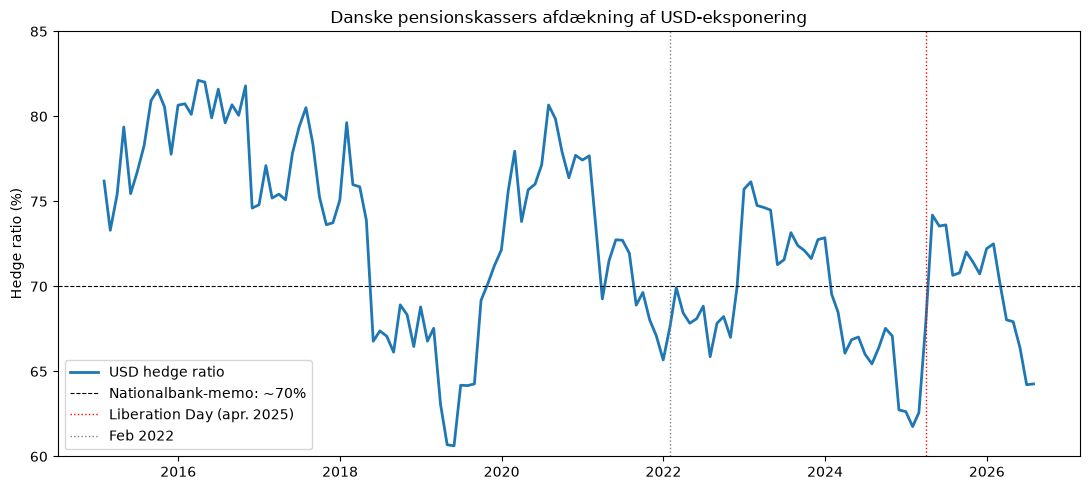

Min: 60.6%  Max: 82.1%
Jan 2025: [61.75150912] -> Apr 2025: [74.18902791]
Afdækket USD-eksponering: start (2015-01-31) = 495.3   slut (2026-07-31) = 1231.3
Uafdækket USD-eksponering: start (2015-01-31) = 154.7   slut (2026-07-31) = 684.8
Hedge ratio (%): start (2015-01-31) = 76.2   slut (2026-07-31) = 64.3


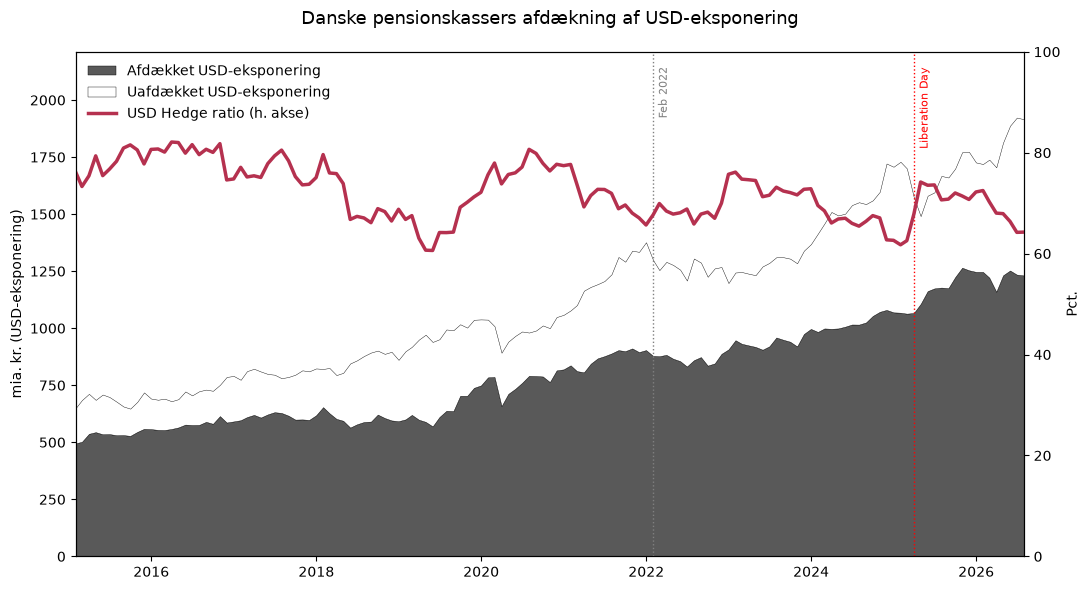

In [84]:
%pip install matplotlib
import matplotlib.pyplot as plt

# ============================================================
# USD hedge ratio — er afdækningsgraden tidsvarierende?
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

# tjek
print(d[["month","USD_hedge_ratio","hr"]].head(3))
print(d["hr"].describe())

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(d["month"], d["hr"], lw=2, color="tab:blue", label="USD hedge ratio")
ax.set_ylim(60, 85)   # (min, max) i procent — juster tallene til det, der passer til din data
ax.axhline(70, color="black", lw=0.8, ls="--", label="Nationalbank-memo: ~70%")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":", label="Liberation Day (apr. 2025)")
ax.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":", label="Feb 2022")

ax.set_title("Danske pensionskassers afdækning af USD-eksponering")
ax.set_ylabel("Hedge ratio (%)")
ax.legend()
plt.tight_layout()
plt.show()

# nøgletal til vejledermødet
apr25 = d.loc[d["month"] == "2025-04-30", "hr"].values
jan25 = d.loc[d["month"] == "2025-01-31", "hr"].values
print(f"Min: {d['hr'].min():.1f}%  Max: {d['hr'].max():.1f}%")
print(f"Jan 2025: {jan25} -> Apr 2025: {apr25}")

# ============================================================
# USD-eksponering: afdækket vs. uafdækket, med hedge ratio
# Efterligner Nationalbankens figur (stablet areal + linje på højre akse)
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio","USD_afd_total","USD_uafd_total","USD_eksp_total"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

fig, ax1 = plt.subplots(figsize=(11,6))

for col, navn in [("USD_afd_total", "Afdækket USD-eksponering"),
                   ("USD_uafd_total", "Uafdækket USD-eksponering"),
                   ("hr", "Hedge ratio (%)")]:
    start = d[col].iloc[0]
    slut = d[col].iloc[-1]
    print(f"{navn}: start ({d['month'].iloc[0].date()}) = {start:.1f}   "
          f"slut ({d['month'].iloc[-1].date()}) = {slut:.1f}")

# Stablet areal: afdækket (mørkegrå) nederst, uafdækket (hvid) ovenpå
ax1.stackplot(
    d["month"],
    d["USD_afd_total"], d["USD_uafd_total"],
    labels=["Afdækket USD-eksponering", "Uafdækket USD-eksponering"],
    colors=["#595959", "white"],
    edgecolor="black", linewidth=0.3,
)
ax1.set_ylabel("mia. kr. (USD-eksponering)")
ax1.set_ylim(0, d["USD_eksp_total"].max() * 1.15)
ax1.set_xlim(pd.Timestamp("2015-01-31"), pd.Timestamp("2026-07-31"))

# Hedge ratio på højre akse
ax2 = ax1.twinx()
ax2.plot(d["month"], d["hr"], color="#b5314f", lw=2.5, label="USD Hedge ratio (h. akse)")
ax2.set_ylabel("Pct.")
ax2.set_ylim(0, 100)  # juster til dataens variation

# Marker Liberation Day
offset = pd.Timedelta(days=20)

ax1.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":")
ax1.text(pd.Timestamp("2025-04-01") + offset, ax1.get_ylim()[1]*0.97, "Liberation Day",
         color="red", fontsize=8, rotation=90, va="top", ha="left")

ax1.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":")
ax1.text(pd.Timestamp("2022-02-01") + offset, ax1.get_ylim()[1]*0.97, "Feb 2022",
         color="gray", fontsize=8, rotation=90, va="top", ha="left")

ax1.set_title("Danske pensionskassers afdækning af USD-eksponering", fontsize=13, loc="center", pad=20)
# Fælles legend for begge akser
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

# LP-Projections - TPU, GPR, GPR_USA


=== TPU ===
 h  coef    se     t     p   sig
 0 0.451 0.516 0.874 0.382      
 1 0.887 0.984 0.901 0.368      
 2 0.131 1.167 0.112 0.911      
 3 0.007 1.000 0.007 0.994      
 4 0.310 0.942 0.329 0.742      
 5 0.672 1.163 0.578 0.563      
 6 1.570 0.981 1.601 0.109 (68%)
 7 2.020 0.914 2.210 0.027    **
 8 1.745 1.157 1.508 0.131 (68%)
 9 1.948 1.130 1.724 0.085     *
10 1.153 1.113 1.036 0.300 (68%)
11 1.418 1.099 1.290 0.197 (68%)
12 1.674 1.059 1.581 0.114 (68%)
13 1.808 1.368 1.322 0.186 (68%)
14 2.070 1.290 1.604 0.109 (68%)
15 2.063 1.319 1.564 0.118 (68%)
16 2.036 1.261 1.615 0.106 (68%)
17 2.802 1.427 1.963 0.050    **
18 2.371 1.824 1.300 0.194 (68%)

=== GPR (globalt) ===
 h   coef    se      t     p   sig
 0 -0.003 0.173 -0.015 0.988      
 1  0.426 0.343  1.244 0.214 (68%)
 2 -0.073 0.319 -0.228 0.819      
 3 -0.174 0.413 -0.421 0.674      
 4 -0.041 0.402 -0.101 0.919      
 5  0.296 0.514  0.577 0.564      
 6  0.718 0.474  1.516 0.130 (68%)
 7  0.722 0.560  1.291 0

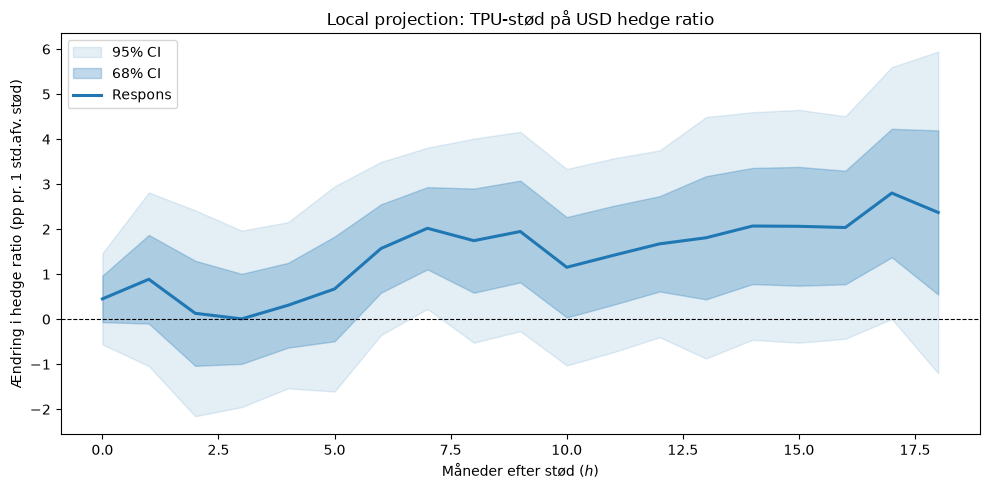

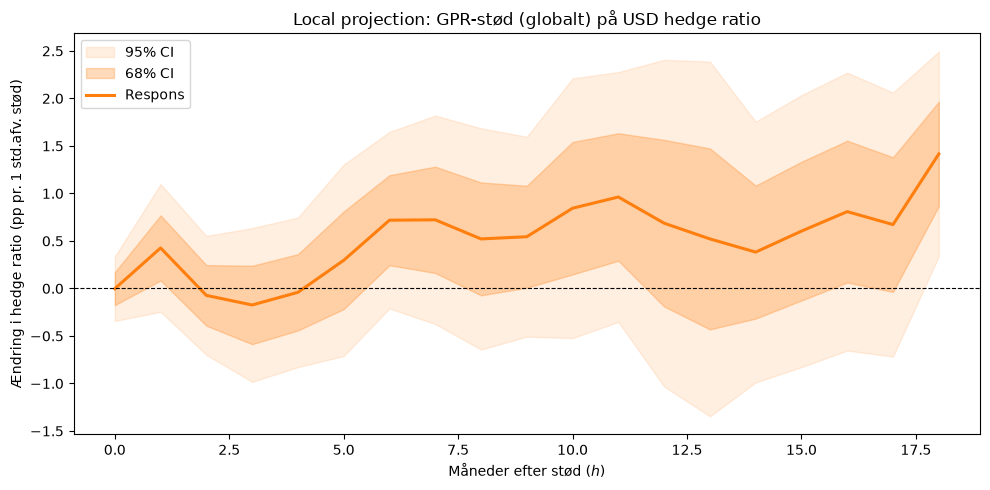

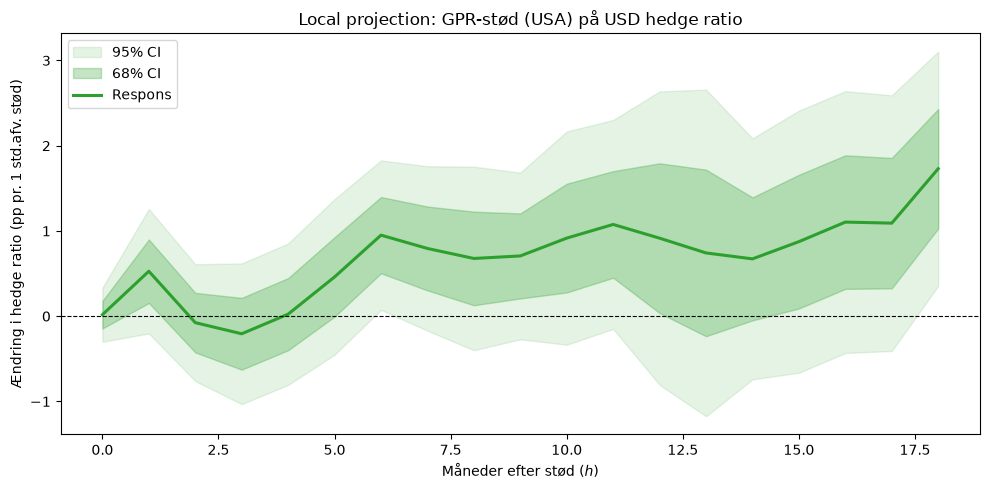

In [85]:
from scipy import stats

def lp_lagaug(master, indeks, H=18, LP_LAGS=2, NW_LAG=18):
    """Lag-augmenteret LP: effekt af et usikkerhedsstød på USD hedge ratio.
    'indeks' er navnet på det log-standardiserede indeks, fx 'lnTPU_z'."""
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["hr"] = d["USD_hedge_ratio"] * 100

    # Lag-augmentation: den foregående måneds værdi af regressoren som kontrol
    d[f"{indeks}_lag1"] = d[indeks].shift(1)

    # Stationære kontroller (laggede), jf. Jordà
    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    lag_termer = [f"{indeks}_lag1"]
    for var in kontroller:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            lag_termer.append(f"{var}_l{L}")
    kontrol_formel = " + ".join(lag_termer)

    res = []
    for h in range(H + 1):
        d[f"hr_lead{h}"] = d["hr"].shift(-h) - d["hr"].shift(1)   # long difference
        sub = d.dropna(subset=[f"hr_lead{h}", indeks] + lag_termer)
        m = smf.ols(f"hr_lead{h} ~ {indeks} + {kontrol_formel}",
                    data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})
        res.append({"h": h, "coef": m.params[indeks],
                    "se": m.bse[indeks], "n": int(m.nobs)})

    lp = pd.DataFrame(res)
    lp["ci68_low"], lp["ci68_high"] = lp["coef"]-lp["se"],      lp["coef"]+lp["se"]
    lp["ci95_low"], lp["ci95_high"] = lp["coef"]-1.96*lp["se"], lp["coef"]+1.96*lp["se"]
    lp["t"] = lp["coef"]/lp["se"]
    lp["p"] = 2*(1 - stats.norm.cdf(lp["t"].abs()))
    lp["sig"] = np.where(lp["p"]<0.05, "**",
                np.where(lp["p"]<0.10, "*",
                np.where(lp["t"].abs()>1, "(68%)", "")))
    return lp

def plot_lp(lp, titel, farve="tab:blue"):
    fig, ax = plt.subplots(figsize=(10,5))
    ax.fill_between(lp["h"], lp["ci95_low"], lp["ci95_high"], color=farve, alpha=0.12, label="95% CI")
    ax.fill_between(lp["h"], lp["ci68_low"], lp["ci68_high"], color=farve, alpha=0.28, label="68% CI")
    ax.plot(lp["h"], lp["coef"], color=farve, lw=2.2, label="Respons")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("Måneder efter stød ($h$)")
    ax.set_ylabel("Ændring i hedge ratio (pp pr. 1 std.afv. stød)")
    ax.set_title(titel)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Kør for alle tre indeks
lp_tpu       = lp_lagaug(master, "lnTPU_z")
lp_gpr       = lp_lagaug(master, "lnGPR_z")
lp_gpr_usa   = lp_lagaug(master, "lnGPRC_USA_z")

for navn, lp in [("TPU", lp_tpu), ("GPR (globalt)", lp_gpr), ("GPR (USA)", lp_gpr_usa)]:
    print(f"\n=== {navn} ===")
    print(lp[["h","coef","se","t","p","sig"]].round(3).to_string(index=False))

plot_lp(lp_tpu,     "Local projection: TPU-stød på USD hedge ratio", "tab:blue")
plot_lp(lp_gpr,     "Local projection: GPR-stød (globalt) på USD hedge ratio", "tab:orange")
plot_lp(lp_gpr_usa, "Local projection: GPR-stød (USA) på USD hedge ratio", "tab:green")

# LP-Projections - USD apprecierer den eller deprecierer den?


=== USD ~ TPU ===
 h   coef    se      t     p
 0 -0.252 0.222 -1.132 0.258
 1 -0.496 0.385 -1.288 0.198
 2 -0.251 0.541 -0.465 0.642
 3  0.235 0.561  0.420 0.675
 4  0.403 0.628  0.642 0.521
 5  0.038 0.765  0.050 0.960
 6 -0.380 0.769 -0.494 0.621
 7 -0.374 0.744 -0.502 0.615
 8 -0.252 0.817 -0.309 0.758
 9  0.010 0.885  0.011 0.991
10 -0.278 1.003 -0.277 0.782
11 -0.046 0.997 -0.046 0.963
12 -0.538 0.841 -0.639 0.523
13 -0.926 0.904 -1.024 0.306
14 -0.954 0.877 -1.088 0.277
15 -1.363 0.884 -1.542 0.123
16 -1.469 0.965 -1.522 0.128
17 -1.346 1.068 -1.261 0.207
18 -1.428 0.912 -1.565 0.118

=== USD ~ GPR_USA ===
 h   coef    se      t     p
 0  0.105 0.144  0.732 0.464
 1 -0.141 0.174 -0.810 0.418
 2  0.108 0.230  0.468 0.640
 3  0.146 0.230  0.636 0.524
 4  0.220 0.273  0.805 0.421
 5 -0.085 0.357 -0.240 0.811
 6  0.051 0.455  0.112 0.911
 7  0.087 0.608  0.143 0.886
 8  0.050 0.666  0.076 0.940
 9 -0.029 0.620 -0.046 0.963
10 -0.152 0.550 -0.275 0.783
11 -0.372 0.540 -0.688 0.491
1

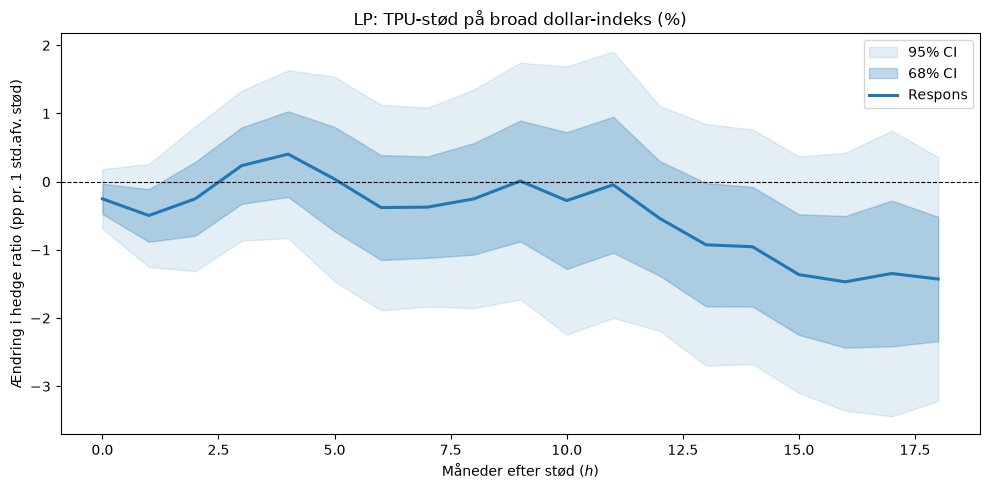

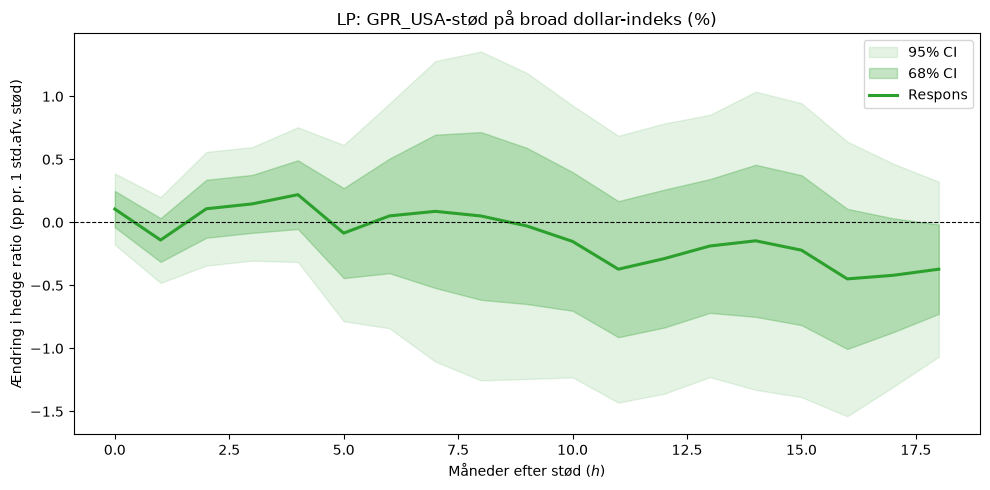

In [86]:
def lp_lagaug_y(master, outcome, indeks, H=18, LP_LAGS=2, NW_LAG=18, skala=1.0):
    """Lag-augmenteret LP med vilkårlig afhængig variabel.
    outcome: kolonnenavn (fx 'lnUSD' for dollar-indeks i log).
    indeks:  det log-standardiserede stød (fx 'lnTPU_z')."""
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["y"] = d[outcome] * skala

    d[f"{indeks}_lag1"] = d[indeks].shift(1)
    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    lag_termer = [f"{indeks}_lag1"]
    for var in kontroller:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            lag_termer.append(f"{var}_l{L}")
    kontrol_formel = " + ".join(lag_termer)

    res = []
    for h in range(H + 1):
        d[f"y_lead{h}"] = d["y"].shift(-h) - d["y"].shift(1)   # long difference
        sub = d.dropna(subset=[f"y_lead{h}", indeks] + lag_termer)
        m = smf.ols(f"y_lead{h} ~ {indeks} + {kontrol_formel}",
                    data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})
        res.append({"h": h, "coef": m.params[indeks],
                    "se": m.bse[indeks], "n": int(m.nobs)})

    lp = pd.DataFrame(res)
    lp["ci68_low"], lp["ci68_high"] = lp["coef"]-lp["se"],      lp["coef"]+lp["se"]
    lp["ci95_low"], lp["ci95_high"] = lp["coef"]-1.96*lp["se"], lp["coef"]+1.96*lp["se"]
    lp["t"] = lp["coef"]/lp["se"]
    lp["p"] = 2*(1 - stats.norm.cdf(lp["t"].abs()))
    return lp

# Dollar-indeks i log*100 -> long difference bliver kumulativ %-appreciering
master["lnUSD"] = np.log(master["DTWEXBGS"])

lp_usd_tpu     = lp_lagaug_y(master, "lnUSD", "lnTPU_z",      skala=100)
lp_usd_gpr_usa = lp_lagaug_y(master, "lnUSD", "lnGPR_z", skala=100)

for navn, lp in [("USD ~ TPU", lp_usd_tpu), ("USD ~ GPR_USA", lp_usd_gpr_usa)]:
    print(f"\n=== {navn} ===")
    print(lp[["h","coef","se","t","p"]].round(3).to_string(index=False))

plot_lp(lp_usd_tpu,     "LP: TPU-stød på broad dollar-indeks (%)", "tab:blue")
plot_lp(lp_usd_gpr_usa, "LP: GPR_USA-stød på broad dollar-indeks (%)", "tab:green")

###LP - GPR shock til EUR/USD 


In [87]:
for p in [1, 2, 3, 4]:

    lp = lp_eurusd(
        master,
        shock="lnGPR_z",
        H=12,
        LP_LAGS=p,
        NW_LAG=18
    )

    print(f"\n=== {p} LAG ===")
    print(
        lp[
            lp["h"].isin([0, 6, 12])
        ][["h", "coef", "se", "p", "n"]]
        .round(4)
        .to_string(index=False)
    )

TypeError: lp_eurusd() got an unexpected keyword argument 'NW_LAG'


=== GPR -> EUR/USD ===
 h    coef     se       t      p   n
 0 -0.0002 0.0026 -0.0891 0.9290 133
 1  0.0008 0.0035  0.2236 0.8231 132
 2 -0.0006 0.0042 -0.1363 0.8916 131
 3 -0.0020 0.0051 -0.3889 0.6974 130
 4 -0.0008 0.0054 -0.1564 0.8757 129
 5 -0.0000 0.0067 -0.0004 0.9997 128
 6  0.0010 0.0076  0.1258 0.8999 127
 7  0.0013 0.0082  0.1552 0.8766 127
 8  0.0012 0.0076  0.1619 0.8714 127
 9  0.0040 0.0071  0.5639 0.5728 127
10  0.0102 0.0070  1.4509 0.1468 126
11  0.0094 0.0065  1.4602 0.1442 125
12  0.0085 0.0071  1.2014 0.2296 124
13  0.0069 0.0074  0.9350 0.3498 123
14  0.0080 0.0089  0.9012 0.3675 122
15  0.0082 0.0087  0.9494 0.3424 121
16  0.0100 0.0076  1.3130 0.1892 120
17  0.0096 0.0058  1.6708 0.0948 119
18  0.0109 0.0050  2.1580 0.0309 118
19  0.0142 0.0061  2.3133 0.0207 117
20  0.0164 0.0064  2.5821 0.0098 116
21  0.0161 0.0054  3.0009 0.0027 115
22  0.0157 0.0064  2.4624 0.0138 114
23  0.0162 0.0065  2.4957 0.0126 113
24  0.0155 0.0056  2.7572 0.0058 112
25  0.0130 0.0

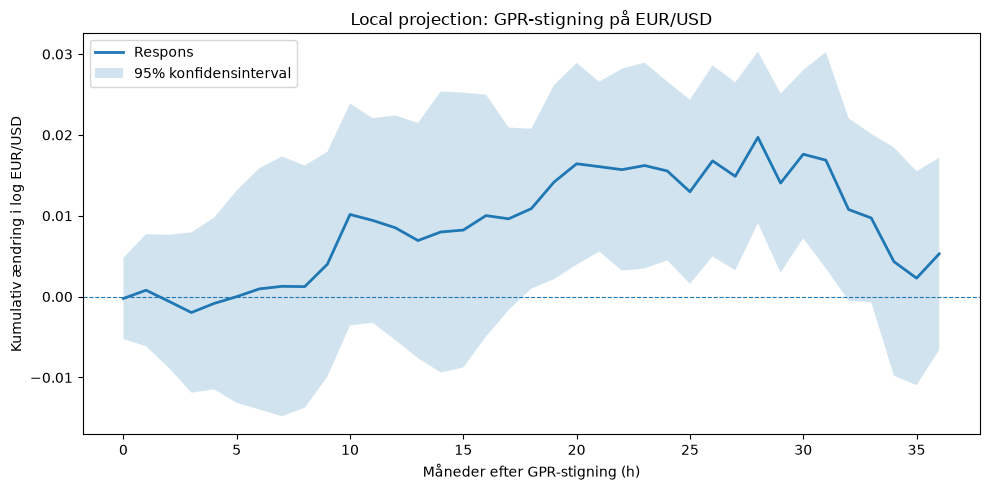

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


# ============================================================
# Local Projection: GPR -> EUR/USD
# ============================================================

def lp_eurusd(
    master,
    shock,
    H=36,
    LP_LAGS=2
):

    # --------------------------------------------------------
    # 1. Kopiér og sorter data
    # --------------------------------------------------------

    d = (
        master
        .copy()
        .sort_values("month")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 2. EUR/USD i log og månedligt afkast
    # --------------------------------------------------------

    d["lnEURUSD"] = np.log(d["EURUSD"])

    d["EURUSD_return"] = d["lnEURUSD"].diff()


    # --------------------------------------------------------
    # 3. Kontrolvariable
    # --------------------------------------------------------

    controls = [
        "ip_growth",
        "nfp_growth",
        "inflation",
        "d_DGS10"
    ]


    # --------------------------------------------------------
    # 4. Lags
    # --------------------------------------------------------

    lag_terms = []

    # Lags af EUR/USD-afkast
    for L in range(1, LP_LAGS + 1):

        d[f"EURUSD_return_L{L}"] = (
            d["EURUSD_return"].shift(L)
        )

        lag_terms.append(
            f"EURUSD_return_L{L}"
        )


    # Lags af GPR
    for L in range(1, LP_LAGS + 1):

        d[f"{shock}_L{L}"] = (
            d[shock].shift(L)
        )

        lag_terms.append(
            f"{shock}_L{L}"
        )


    # Lags af kontrolvariable
    for var in controls:

        for L in range(1, LP_LAGS + 1):

            d[f"{var}_L{L}"] = (
                d[var].shift(L)
            )

            lag_terms.append(
                f"{var}_L{L}"
            )


    lag_formula = " + ".join(lag_terms)


    # --------------------------------------------------------
    # 5. Estimér Local Projection for hver horisont
    # --------------------------------------------------------

    results = []

    for h in range(H + 1):

        # Kumulativ ændring i log EUR/USD
        #
        # h = 0:
        # ln(EURUSD_t) - ln(EURUSD_{t-1})
        #
        # h = 1:
        # ln(EURUSD_{t+1}) - ln(EURUSD_{t-1})
        #
        # osv.

        d[f"y_h{h}"] = (
            d["lnEURUSD"].shift(-h)
            - d["lnEURUSD"].shift(1)
        )


        # ----------------------------------------------------
        # Observationer til denne horisont
        # ----------------------------------------------------

        sub = d.dropna(
            subset=[
                f"y_h{h}",
                shock
            ] + lag_terms
        )


        # ----------------------------------------------------
        # LP-regression
        # ----------------------------------------------------

        formula = (
            f"y_h{h} ~ {shock} + {lag_formula}"
        )


        model = smf.ols(
            formula=formula,
            data=sub
        ).fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": h
            }
        )


        # ----------------------------------------------------
        # Gem resultat
        # ----------------------------------------------------

        results.append({

            "h": h,

            "coef": model.params[shock],

            "se": model.bse[shock],

            "t": model.tvalues[shock],

            "p": model.pvalues[shock],

            "n": int(model.nobs)
        })


    # --------------------------------------------------------
    # 6. Saml resultater
    # --------------------------------------------------------

    lp = pd.DataFrame(results)


    # 95% konfidensinterval

    lp["ci95_low"] = (
        lp["coef"]
        - 1.96 * lp["se"]
    )

    lp["ci95_high"] = (
        lp["coef"]
        + 1.96 * lp["se"]
    )


    return lp


# ============================================================
# GPR -> EUR/USD
# ============================================================

lp_gpr_eurusd = lp_eurusd(
    master,
    shock="lnGPR_z",
    H=36,
    LP_LAGS=2
)


# ============================================================
# Resultattabel
# ============================================================

print("\n=== GPR -> EUR/USD ===")

print(
    lp_gpr_eurusd[
        [
            "h",
            "coef",
            "se",
            "t",
            "p",
            "n"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# Figur
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    lp_gpr_eurusd["h"],
    lp_gpr_eurusd["coef"],
    linewidth=2,
    label="Respons"
)

ax.fill_between(
    lp_gpr_eurusd["h"],
    lp_gpr_eurusd["ci95_low"],
    lp_gpr_eurusd["ci95_high"],
    alpha=0.20,
    label="95% konfidensinterval"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xlabel(
    "Måneder efter GPR-stigning (h)"
)

ax.set_ylabel(
    "Kumulativ ændring i log EUR/USD"
)

ax.set_title(
    "Local projection: GPR-stigning på EUR/USD"
)

ax.legend()

plt.tight_layout()

plt.show()

VIX robusthedstest

In [98]:
# ============================================================
# ROBUSTHED: GPR -> EUR/USD med VIX
# ============================================================

def lp_eurusd_vix(
    master,
    shock="lnGPR_z",
    vix="lnVIXCLS_z",
    H=36,
    LP_LAGS=2
):

    d = (
        master
        .copy()
        .sort_values("month")
        .reset_index(drop=True)
    )

    # EUR/USD
    d["lnEURUSD"] = np.log(d["EURUSD"])
    d["EURUSD_return"] = d["lnEURUSD"].diff()

    controls = [
        "ip_growth",
        "nfp_growth",
        "inflation",
        "d_DGS10"
    ]

    lag_terms = []

    # Lags af EUR/USD-afkast
    for L in range(1, LP_LAGS + 1):
        d[f"EURUSD_return_L{L}"] = (
            d["EURUSD_return"].shift(L)
        )
        lag_terms.append(f"EURUSD_return_L{L}")

    # Lags af GPR
    for L in range(1, LP_LAGS + 1):
        d[f"{shock}_L{L}"] = d[shock].shift(L)
        lag_terms.append(f"{shock}_L{L}")

    # Lags af VIX
    for L in range(1, LP_LAGS + 1):
        d[f"{vix}_L{L}"] = d[vix].shift(L)
        lag_terms.append(f"{vix}_L{L}")

    # Lags af kontrolvariable
    for var in controls:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_L{L}"] = d[var].shift(L)
            lag_terms.append(f"{var}_L{L}")

    lag_formula = " + ".join(lag_terms)

    results = []

    for h in range(H + 1):

        # Kumulativ ændring i log EUR/USD
        d[f"y_h{h}"] = (
            d["lnEURUSD"].shift(-h)
            - d["lnEURUSD"].shift(1)
        )

        sub = d.dropna(
            subset=[
                f"y_h{h}",
                shock,
                vix
            ] + lag_terms
        )

        formula = (
            f"y_h{h} ~ {shock} + {vix} + {lag_formula}"
        )

        model = smf.ols(
            formula=formula,
            data=sub
        ).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": h}
        )

        results.append({
            "h": h,
            "coef_gpr": model.params[shock],
            "se_gpr": model.bse[shock],
            "t_gpr": model.tvalues[shock],
            "p_gpr": model.pvalues[shock],
            "coef_vix": model.params[vix],
            "p_vix": model.pvalues[vix],
            "n": int(model.nobs)
        })

    return pd.DataFrame(results)


# ============================================================
# KØR MODELLEN
# ============================================================

lp_gpr_vix = lp_eurusd_vix(
    master,
    shock="lnGPR_z",
    vix="lnVIXCLS_z",
    H=36,
    LP_LAGS=2
)


# ============================================================
# PRINT RESULTATER
# ============================================================

print("\n=== GPR -> EUR/USD med VIX ===")

print(
    lp_gpr_vix[
        [
            "h",
            "coef_gpr",
            "se_gpr",
            "t_gpr",
            "p_gpr",
            "coef_vix",
            "p_vix",
            "n"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


=== GPR -> EUR/USD med VIX ===
 h  coef_gpr  se_gpr   t_gpr  p_gpr  coef_vix  p_vix   n
 0   -0.0003  0.0026 -0.1149 0.9086   -0.0015 0.6001 133
 1    0.0005  0.0035  0.1364 0.8915   -0.0010 0.7820 132
 2   -0.0011  0.0041 -0.2744 0.7838    0.0018 0.7059 131
 3   -0.0024  0.0051 -0.4796 0.6315    0.0004 0.9401 130
 4   -0.0011  0.0055 -0.2005 0.8411    0.0011 0.8724 129
 5    0.0001  0.0065  0.0142 0.9886    0.0024 0.7830 128
 6    0.0011  0.0074  0.1454 0.8844    0.0018 0.8272 127
 7    0.0013  0.0079  0.1606 0.8724    0.0051 0.4740 127
 8    0.0012  0.0073  0.1627 0.8707    0.0059 0.4279 127
 9    0.0041  0.0066  0.6139 0.5393    0.0073 0.3765 127
10    0.0100  0.0065  1.5453 0.1223    0.0090 0.2667 126
11    0.0092  0.0062  1.4729 0.1408    0.0067 0.3836 125
12    0.0082  0.0069  1.1845 0.2362    0.0055 0.4057 124
13    0.0067  0.0073  0.9267 0.3541    0.0042 0.5725 123
14    0.0074  0.0087  0.8557 0.3922    0.0059 0.4590 122
15    0.0078  0.0085  0.9197 0.3577   -0.0006 0.9403 121

TPU


=== TPU -> EUR/USD ===
 h    coef     se       t      p   n
 0  0.0053 0.0054  0.9884 0.3229 133
 1 -0.0003 0.0081 -0.0359 0.9713 132
 2 -0.0054 0.0110 -0.4893 0.6246 131
 3 -0.0120 0.0112 -1.0772 0.2814 130
 4 -0.0066 0.0131 -0.5091 0.6107 129
 5 -0.0004 0.0142 -0.0264 0.9789 128
 6  0.0018 0.0136  0.1288 0.8975 127
 7  0.0062 0.0163  0.3783 0.7052 127
 8  0.0014 0.0171  0.0795 0.9366 127
 9  0.0018 0.0185  0.0964 0.9232 127
10  0.0039 0.0190  0.2055 0.8371 126
11  0.0040 0.0176  0.2283 0.8194 125
12  0.0090 0.0171  0.5248 0.5998 124
13  0.0119 0.0177  0.6698 0.5030 123
14  0.0201 0.0179  1.1235 0.2612 122
15  0.0231 0.0159  1.4514 0.1467 121
16  0.0190 0.0185  1.0287 0.3036 120
17  0.0181 0.0192  0.9404 0.3470 119
18  0.0148 0.0204  0.7242 0.4689 118
19  0.0117 0.0193  0.6087 0.5427 117
20  0.0100 0.0191  0.5240 0.6003 116
21  0.0049 0.0181  0.2707 0.7866 115
22 -0.0025 0.0168 -0.1509 0.8801 114
23 -0.0007 0.0153 -0.0473 0.9623 113
24  0.0031 0.0162  0.1925 0.8473 112
25  0.0021 0.0

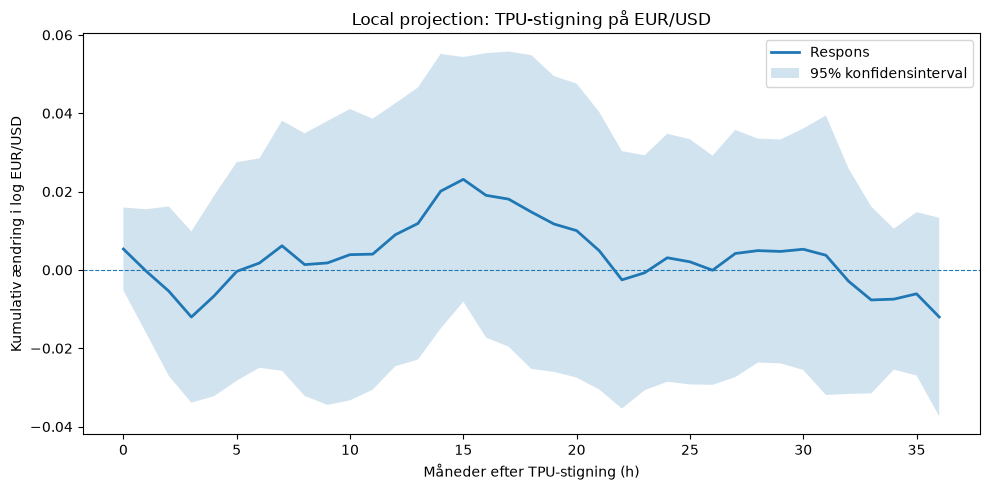

In [99]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


# ============================================================
# Local Projection: TPU -> EUR/USD
# Baseline specification
# ============================================================

def lp_tpu_eurusd(
    master,
    shock="lnTPU_z",
    H=36,
    LP_LAGS=2
):

    # --------------------------------------------------------
    # 1. Kopiér og sorter data
    # --------------------------------------------------------

    d = (
        master
        .copy()
        .sort_values("month")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # 2. EUR/USD i log og månedligt afkast
    # --------------------------------------------------------

    d["lnEURUSD"] = np.log(d["EURUSD"])

    d["EURUSD_return"] = d["lnEURUSD"].diff()


    # --------------------------------------------------------
    # 3. Kontrolvariable
    # --------------------------------------------------------

    controls = [
        "ip_growth",
        "nfp_growth",
        "inflation",
        "d_DGS10"
    ]


    # --------------------------------------------------------
    # 4. Lags
    # --------------------------------------------------------

    lag_terms = []


    # Lags af EUR/USD-afkast
    for L in range(1, LP_LAGS + 1):

        d[f"EURUSD_return_L{L}"] = (
            d["EURUSD_return"].shift(L)
        )

        lag_terms.append(
            f"EURUSD_return_L{L}"
        )


    # Lags af TPU
    for L in range(1, LP_LAGS + 1):

        d[f"{shock}_L{L}"] = (
            d[shock].shift(L)
        )

        lag_terms.append(
            f"{shock}_L{L}"
        )


    # Lags af kontrolvariable
    for var in controls:

        for L in range(1, LP_LAGS + 1):

            d[f"{var}_L{L}"] = (
                d[var].shift(L)
            )

            lag_terms.append(
                f"{var}_L{L}"
            )


    lag_formula = " + ".join(lag_terms)


    # --------------------------------------------------------
    # 5. Local Projection for hver horizon
    # --------------------------------------------------------

    results = []


    for h in range(H + 1):


        # ----------------------------------------------------
        # Kumulativ ændring i log EUR/USD
        #
        # h = 0:
        # ln(EUR/USD_t) - ln(EUR/USD_{t-1})
        #
        # h = 1:
        # ln(EUR/USD_{t+1}) - ln(EUR/USD_{t-1})
        #
        # osv.
        # ----------------------------------------------------

        d[f"y_h{h}"] = (
            d["lnEURUSD"].shift(-h)
            - d["lnEURUSD"].shift(1)
        )


        # ----------------------------------------------------
        # Observationer til denne horizon
        # ----------------------------------------------------

        sub = d.dropna(
            subset=[
                f"y_h{h}",
                shock
            ] + lag_terms
        )


        # ----------------------------------------------------
        # LP-regression
        # ----------------------------------------------------

        formula = (
            f"y_h{h} ~ {shock} + {lag_formula}"
        )


        model = smf.ols(
            formula=formula,
            data=sub
        ).fit(
            cov_type="HAC",
            cov_kwds={
                # Jordà: HAC bandwidth følger horizon
                "maxlags": h
            }
        )


        # ----------------------------------------------------
        # Gem TPU-resultat
        # ----------------------------------------------------

        results.append({

            "h": h,

            "coef": model.params[shock],

            "se": model.bse[shock],

            "t": model.tvalues[shock],

            "p": model.pvalues[shock],

            "n": int(model.nobs)
        })


    # --------------------------------------------------------
    # 6. Saml resultater
    # --------------------------------------------------------

    lp = pd.DataFrame(results)


    # --------------------------------------------------------
    # 7. 95% konfidensinterval
    # --------------------------------------------------------

    lp["ci95_low"] = (
        lp["coef"]
        - 1.96 * lp["se"]
    )

    lp["ci95_high"] = (
        lp["coef"]
        + 1.96 * lp["se"]
    )


    return lp


# ============================================================
# KØR TPU-BASELINE
# ============================================================

lp_tpu_eurusd = lp_tpu_eurusd(
    master,
    shock="lnTPU_z",
    H=36,
    LP_LAGS=2
)


# ============================================================
# RESULTATTABEL
# ============================================================

print("\n=== TPU -> EUR/USD ===")

print(
    lp_tpu_eurusd[
        [
            "h",
            "coef",
            "se",
            "t",
            "p",
            "n"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# FIGUR
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)


ax.plot(
    lp_tpu_eurusd["h"],
    lp_tpu_eurusd["coef"],
    linewidth=2,
    label="Respons"
)


ax.fill_between(
    lp_tpu_eurusd["h"],
    lp_tpu_eurusd["ci95_low"],
    lp_tpu_eurusd["ci95_high"],
    alpha=0.20,
    label="95% konfidensinterval"
)


ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)


ax.set_xlabel(
    "Måneder efter TPU-stigning (h)"
)


ax.set_ylabel(
    "Kumulativ ændring i log EUR/USD"
)


ax.set_title(
    "Local projection: TPU-stigning på EUR/USD"
)


ax.legend()


plt.tight_layout()
plt.show()